In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

In [8]:
# Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Base Classifiers
lr = LogisticRegression(max_iter=5000)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [11]:
# Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('knn', knn)
    ],
    voting='hard'
)

In [12]:
# Train Model
voting_clf.fit(X_train, y_train)

# Prediction
y_pred = voting_clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Voting Ensemble Accuracy:", round(accuracy*100, 2), "%")

Voting Ensemble Accuracy: 96.49 %


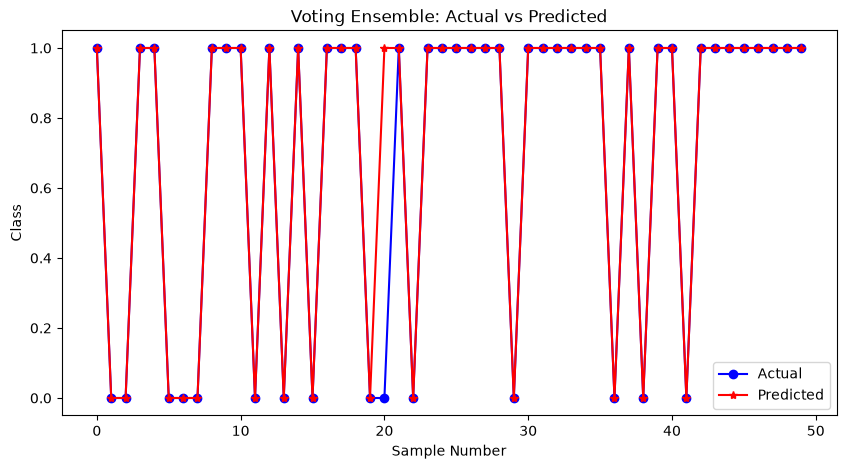

In [13]:
# Graph: Actual vs Predicted

plt.figure(figsize=(10,5))

plt.plot(y_test[:50], 'bo-', label='Actual')
plt.plot(y_pred[:50], 'r*-', label='Predicted')

plt.title("Voting Ensemble: Actual vs Predicted")
plt.xlabel("Sample Number")
plt.ylabel("Class")
plt.legend()

plt.show()

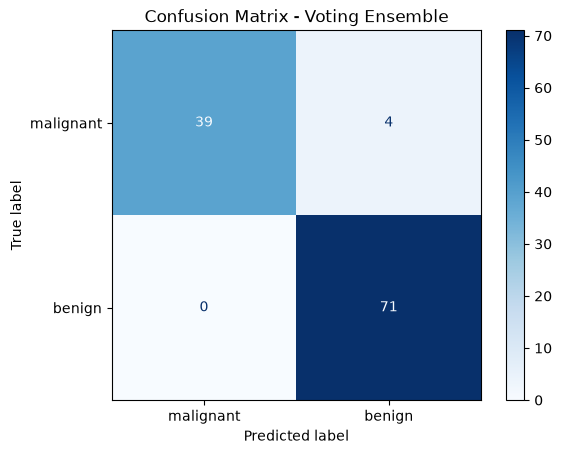

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Voting Ensemble")
plt.show()

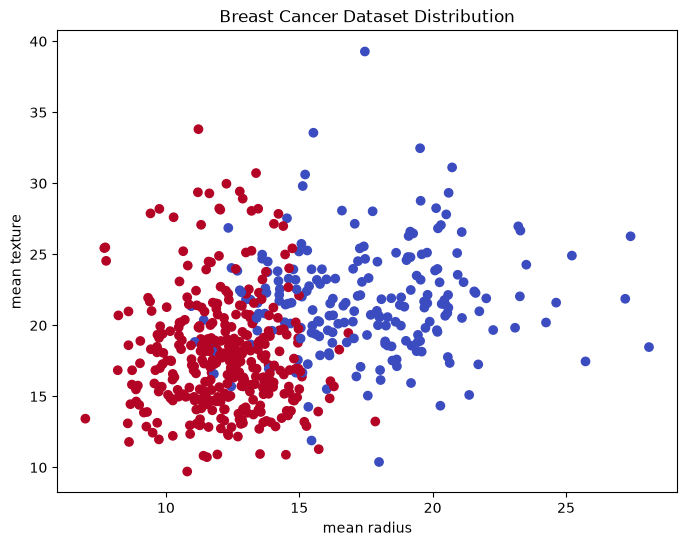

In [14]:
# Dataset Visualisation
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],      # mean radius
    X[:,1],      # mean texture
    c=y,
    cmap='coolwarm'
)

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])

plt.title("Breast Cancer Dataset Distribution")

plt.show()